# Time Series Forecasting for Cryptocurrency Prices

This notebook implements time series forecasting models to predict future cryptocurrency prices.
We will compare ARIMA and Prophet models with evaluation metrics (MAE, RMSE).

In [10]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Ensure the notebook runs from the project root
project_root = Path(r"D:/BTLDATA/DATA_MINING_PROJECT")
os.chdir(project_root)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [17]:
# Load processed data
df = pd.read_csv("data/processed/crypto_features_clean.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['coin', 'Date'])

print(f"Data loaded: {df.shape[0]} rows, {df['coin'].nunique()} coins")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Bitcoin rows: {len(df[df['coin'] == 'Bitcoin'])}")
df.head()

Data loaded: 36921 rows, 23 coins
Date range: 2013-05-06 23:59:59 to 2021-07-06 23:59:59
Bitcoin rows: 2984


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,coin,log_return,vol_7d
0,8,Aave,AAVE,2020-10-12 23:59:59,54.421418,48.754077,49.661573,52.238692,1.354836e+06,2.629157e+08,Aave,0.050609,0.109557
1,9,Aave,AAVE,2020-10-13 23:59:59,57.481904,49.598735,52.238392,51.124317,1.386221e+06,2.573071e+08,Aave,-0.021563,0.051472
2,10,Aave,AAVE,2020-10-14 23:59:59,57.853946,49.629529,51.372899,51.316518,3.132405e+06,2.582744e+08,Aave,0.003752,0.038799
3,11,Aave,AAVE,2020-10-15 23:59:59,52.080685,44.018325,51.387610,44.019183,5.883146e+06,2.215471e+08,Aave,-0.153387,0.074785
4,12,Aave,AAVE,2020-10-16 23:59:59,43.906730,39.142957,42.890607,39.495844,5.285520e+07,3.650715e+08,Aave,-0.108430,0.078143


## Forecasting Function

We'll create a function that can forecast prices for any coin using different models.

In [12]:
def forecast_coin_prices(coin_name, model_type='arima', periods=30, train_split=0.8):
    """
    Forecast cryptocurrency prices using ARIMA or Prophet
    
    Parameters:
    - coin_name: Name of the cryptocurrency
    - model_type: 'arima' or 'prophet'
    - periods: Number of days to forecast
    - train_split: Fraction of data for training
    
    Returns:
    - forecast_df: DataFrame with historical and forecasted prices
    - metrics: Dictionary with MAE and RMSE
    """
    
    # Filter data for the coin
    coin_data = df[df['coin'] == coin_name].copy()
    coin_data = coin_data.set_index('Date')['Close'].dropna()
    
    print(f"Debug: {coin_name} has {len(coin_data)} data points")
    
    if len(coin_data) < 50:  # Reduced threshold
        print(f"Not enough data for {coin_name}: {len(coin_data)} points")
        return None, None
    
    # Split train/test
    train_size = int(len(coin_data) * train_split)
    train = coin_data[:train_size]
    test = coin_data[train_size:]
    
    if model_type == 'arima':
        # Fit ARIMA model
        model = ARIMA(train, order=(5,1,0))
        model_fit = model.fit()
        
        # Forecast
        forecast = model_fit.forecast(steps=len(test))
        
    elif model_type == 'prophet':
        # Prepare data for Prophet
        prophet_df = pd.DataFrame({
            'ds': train.index,
            'y': train.values
        })
        
        # Fit Prophet model
        model = Prophet(daily_seasonality=True, yearly_seasonality=True)
        model.fit(prophet_df)
        
        # Forecast
        future = model.make_future_dataframe(periods=len(test))
        forecast_result = model.predict(future)
        forecast = forecast_result['yhat'][-len(test):]
    
    # Calculate metrics
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    
    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': np.mean(np.abs((test - forecast) / test)) * 100
    }
    
    # Create forecast DataFrame
    forecast_df = pd.DataFrame({
        'Date': test.index,
        'Historical': test.values,
        'Forecast': forecast.values
    })
    
    return forecast_df, metrics

print("Forecasting function defined!")

Forecasting function defined!


## Test Forecasting on Bitcoin

Let's test both ARIMA and Prophet models on Bitcoin data.

In [19]:
# Test on Bitcoin
coin_name = 'Bitcoin'

# ARIMA forecast
arima_forecast, arima_metrics = forecast_coin_prices(coin_name, 'arima')

# Prophet forecast
prophet_forecast, prophet_metrics = forecast_coin_prices(coin_name, 'prophet')

print(f"ARIMA Metrics for {coin_name}:")
print(arima_metrics)
print(f"\nProphet Metrics for {coin_name}:")
print(prophet_metrics)

Debug: Bitcoin has 2984 data points
Debug: Bitcoin has 2984 data points


21:11:03 - cmdstanpy - INFO - Chain [1] start processing
21:11:04 - cmdstanpy - INFO - Chain [1] done processing


ARIMA Metrics for Bitcoin:
{'MAE': 13590.920009870762, 'RMSE': np.float64(21800.43310639265), 'MAPE': np.float64(40.51608042115636)}

Prophet Metrics for Bitcoin:
{'MAE': 11754.68496581458, 'RMSE': np.float64(19206.20338125136), 'MAPE': nan}


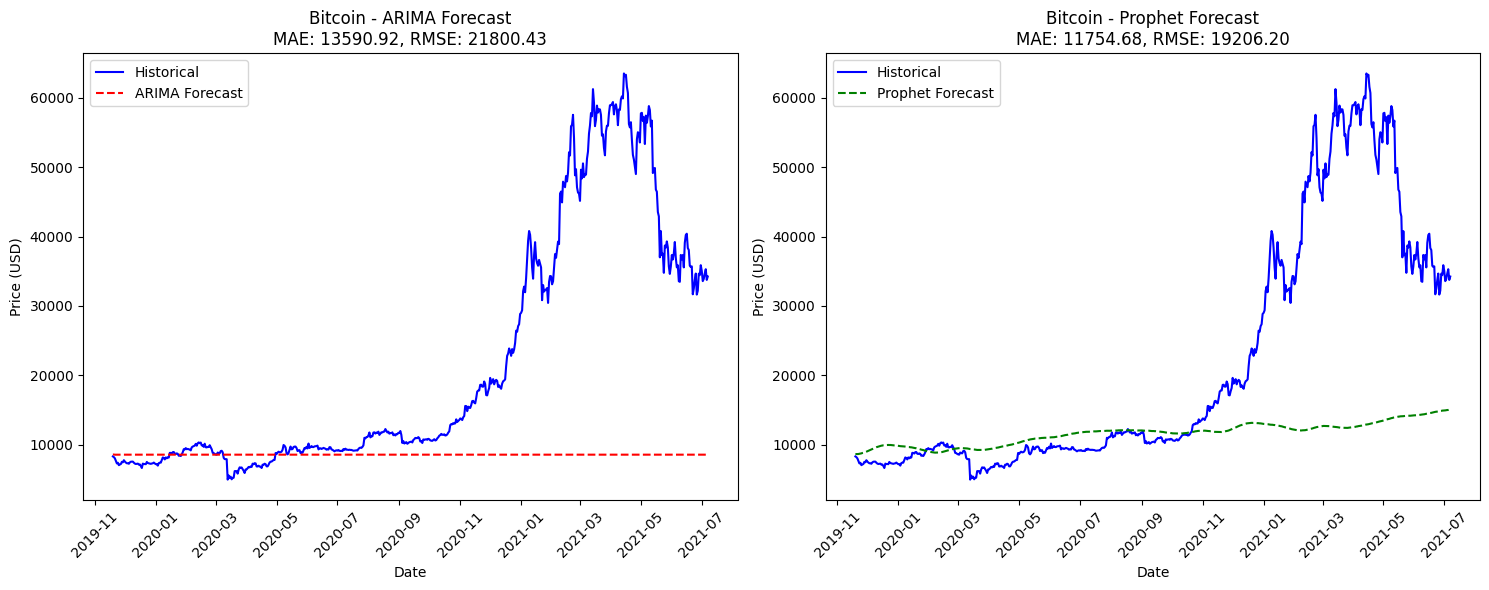

In [20]:
# Visualize forecasts
plt.figure(figsize=(15, 6))

# ARIMA plot
plt.subplot(1, 2, 1)
plt.plot(arima_forecast['Date'], arima_forecast['Historical'], label='Historical', color='blue')
plt.plot(arima_forecast['Date'], arima_forecast['Forecast'], label='ARIMA Forecast', color='red', linestyle='--')
plt.title(f'{coin_name} - ARIMA Forecast\nMAE: {arima_metrics["MAE"]:.2f}, RMSE: {arima_metrics["RMSE"]:.2f}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)

# Prophet plot
plt.subplot(1, 2, 2)
plt.plot(prophet_forecast['Date'], prophet_forecast['Historical'], label='Historical', color='blue')
plt.plot(prophet_forecast['Date'], prophet_forecast['Forecast'], label='Prophet Forecast', color='green', linestyle='--')
plt.title(f'{coin_name} - Prophet Forecast\nMAE: {prophet_metrics["MAE"]:.2f}, RMSE: {prophet_metrics["RMSE"]:.2f}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Future Price Prediction

Now let's predict future prices (next 30 days) for Bitcoin.

In [21]:
def predict_future_prices(coin_name, model_type='arima', periods=30):
    """
    Predict future prices using the full historical data
    """
    
    # Get full data for the coin
    coin_data = df[df['coin'] == coin_name].copy()
    coin_data = coin_data.set_index('Date')['Close'].dropna()
    
    if model_type == 'arima':
        # Fit ARIMA on full data
        model = ARIMA(coin_data, order=(5,1,0))
        model_fit = model.fit()
        
        # Forecast future
        forecast = model_fit.forecast(steps=periods)
        
        # Create future dates
        last_date = coin_data.index[-1]
        future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=periods)
        
    elif model_type == 'prophet':
        # Prepare data for Prophet
        prophet_df = pd.DataFrame({
            'ds': coin_data.index,
            'y': coin_data.values
        })
        
        # Fit Prophet model
        model = Prophet(daily_seasonality=True, yearly_seasonality=True)
        model.fit(prophet_df)
        
        # Forecast future
        future = model.make_future_dataframe(periods=periods)
        forecast_result = model.predict(future)
        
        # Get only future predictions
        future_dates = forecast_result['ds'][-periods:]
        forecast = forecast_result['yhat'][-periods:]
    
    # Create result DataFrame
    future_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Price': forecast.values
    })
    
    return future_df

# Predict future Bitcoin prices
future_arima = predict_future_prices('Bitcoin', 'arima', 30)
future_prophet = predict_future_prices('Bitcoin', 'prophet', 30)

print("Future ARIMA predictions:")
print(future_arima.head())
print("\nFuture Prophet predictions:")
print(future_prophet.head())

21:11:10 - cmdstanpy - INFO - Chain [1] start processing
21:11:11 - cmdstanpy - INFO - Chain [1] done processing


Future ARIMA predictions:
                 Date  Predicted_Price
0 2021-07-07 23:59:59     34141.821879
1 2021-07-08 23:59:59     34132.207138
2 2021-07-09 23:59:59     34092.590902
3 2021-07-10 23:59:59     34120.505927
4 2021-07-11 23:59:59     34108.034198

Future Prophet predictions:
                    Date  Predicted_Price
2984 2021-07-07 23:59:59     42121.561655
2985 2021-07-08 23:59:59     42227.630490
2986 2021-07-09 23:59:59     42347.556143
2987 2021-07-10 23:59:59     42472.257302
2988 2021-07-11 23:59:59     42564.728291


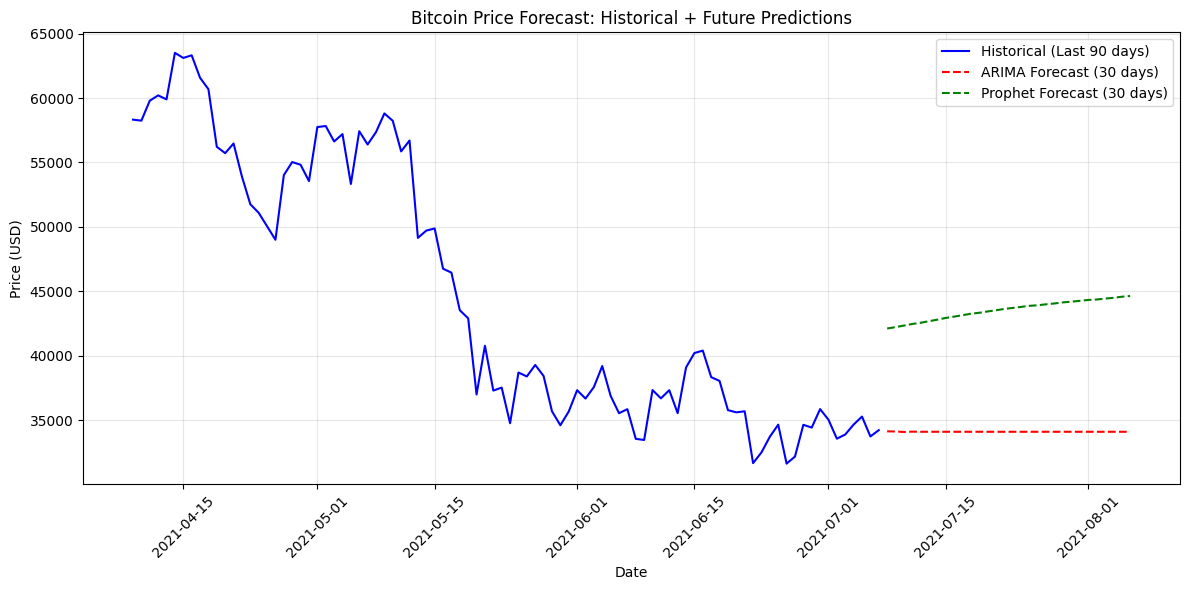


Bitcoin Forecast Summary:
Current Price: $34235.19
ARIMA 30-day prediction: $34109.21 (-0.4%)
Prophet 30-day prediction: $44641.36 (30.4%)


In [22]:
# Visualize future predictions
plt.figure(figsize=(12, 6))

# Get historical data for context
btc_data = df[df['coin'] == 'Bitcoin'].copy()
btc_data = btc_data.set_index('Date')['Close'].dropna()

# Plot historical + future
plt.plot(btc_data.index[-90:], btc_data.values[-90:], label='Historical (Last 90 days)', color='blue')
plt.plot(future_arima['Date'], future_arima['Predicted_Price'], label='ARIMA Forecast (30 days)', color='red', linestyle='--')
plt.plot(future_prophet['Date'], future_prophet['Predicted_Price'], label='Prophet Forecast (30 days)', color='green', linestyle='--')

plt.title('Bitcoin Price Forecast: Historical + Future Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print forecast summary
print(f"\nBitcoin Forecast Summary:")
print(f"Current Price: ${btc_data.iloc[-1]:.2f}")
print(f"ARIMA 30-day prediction: ${future_arima['Predicted_Price'].iloc[-1]:.2f} ({((future_arima['Predicted_Price'].iloc[-1] - btc_data.iloc[-1])/btc_data.iloc[-1]*100):.1f}%)")
print(f"Prophet 30-day prediction: ${future_prophet['Predicted_Price'].iloc[-1]:.2f} ({((future_prophet['Predicted_Price'].iloc[-1] - btc_data.iloc[-1])/btc_data.iloc[-1]*100):.1f}%)")

## Model Comparison Across Multiple Coins

Let's compare ARIMA vs Prophet performance across different coins.

In [23]:
# Test on multiple coins
test_coins = ['Bitcoin', 'Ethereum', 'BinanceCoin', 'Solana', 'Cardano']
results = []

for coin in test_coins:
    try:
        arima_forecast, arima_metrics = forecast_coin_prices(coin, 'arima')
        prophet_forecast, prophet_metrics = forecast_coin_prices(coin, 'prophet')
        
        if arima_metrics and prophet_metrics:
            results.append({
                'Coin': coin,
                'ARIMA_MAE': arima_metrics['MAE'],
                'ARIMA_RMSE': arima_metrics['RMSE'],
                'Prophet_MAE': prophet_metrics['MAE'],
                'Prophet_RMSE': prophet_metrics['RMSE']
            })
    except:
        print(f"Error forecasting {coin}")

# Create comparison table
comparison_df = pd.DataFrame(results)
print("Model Comparison Results:")
print(comparison_df)

# Calculate averages
avg_arima_mae = comparison_df['ARIMA_MAE'].mean()
avg_prophet_mae = comparison_df['Prophet_MAE'].mean()
avg_arima_rmse = comparison_df['ARIMA_RMSE'].mean()
avg_prophet_rmse = comparison_df['Prophet_RMSE'].mean()

print(f"\nAverage Performance:")
print(f"ARIMA - MAE: {avg_arima_mae:.2f}, RMSE: {avg_arima_rmse:.2f}")
print(f"Prophet - MAE: {avg_prophet_mae:.2f}, RMSE: {avg_prophet_rmse:.2f}")

better_model = "ARIMA" if avg_arima_mae < avg_prophet_mae else "Prophet"
print(f"\nBetter performing model: {better_model}")

Debug: Bitcoin has 2984 data points
Debug: Bitcoin has 2984 data points


21:11:16 - cmdstanpy - INFO - Chain [1] start processing
21:11:17 - cmdstanpy - INFO - Chain [1] done processing


Debug: Ethereum has 2153 data points
Debug: Ethereum has 2153 data points


21:11:18 - cmdstanpy - INFO - Chain [1] start processing
21:11:19 - cmdstanpy - INFO - Chain [1] done processing


Debug: BinanceCoin has 1435 data points
Debug: BinanceCoin has 1435 data points


...

Debug: Cardano has 1367 data points


21:11:22 - cmdstanpy - INFO - Chain [1] start processing


Debug: Cardano has 1367 data points


21:11:22 - cmdstanpy - INFO - Chain [1] done processing


Model Comparison Results:
          Coin     ARIMA_MAE    ARIMA_RMSE   Prophet_MAE  Prophet_RMSE
0      Bitcoin  13590.920010  21800.433106  11754.684966  19206.203381
1     Ethereum    897.210546   1315.671355    902.059912   1306.259474
2  BinanceCoin    180.618090    264.881515    187.118871    268.335322
3       Solana      8.727892     10.689623      5.606789      7.045843
4      Cardano      0.716707      0.939617      0.637256      0.850158

Average Performance:
ARIMA - MAE: 2935.64, RMSE: 4678.52
Prophet - MAE: 2570.02, RMSE: 4157.74

Better performing model: Prophet


## Save Forecasting Results

Save the forecasting results for use in the dashboard.

In [ ]:
# Save future predictions for Bitcoin (as example)
future_predictions = pd.DataFrame({
    'Date': future_arima['Date'],
    'ARIMA_Prediction': future_arima['Predicted_Price'],
    'Prophet_Prediction': future_prophet['Predicted_Price']
})

future_predictions.to_csv('data/processed/bitcoin_forecast.csv', index=False)
print("Future predictions saved to data/processed/bitcoin_forecast.csv")

Future predictions saved to data/processed/bitcoin_forecast.csv
Model comparison results saved to data/processed/model_comparison.csv
